<a href="https://colab.research.google.com/github/McBorisson/AI.PINN/blob/main/FunctionEstimator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

In [ ]:
device

'cpu'

# ***Functions***

In [ ]:
def sin(x):
  return torch.sin(x)

def poly(x):
  return x**2

def triangle_wave(x, period=2.0):
    return 2 * torch.abs(2 * (x / period - torch.floor(x / period + 0.5))) - 1

def square_wave(x, period=1.0):
    return torch.sign(torch.sin(2 * torch.pi * x / period))

In [ ]:
functions = {
    "sin(x)": sin,
    "x^2": poly,
    "triangle wave": triangle_wave,
    "square wave": square_wave
}

In [ ]:
def sample_data(func, n = 200, low = -3, high = 3):
  x = torch.linspace(low, high, n).unsqueeze(1).to(device)
  y = func(x)
  return x, y

# ***Architecture***

In [ ]:
class MLP(nn.Module):
  def __init__(self, activation):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(1, 32),
        activation,
        nn.Linear(32, 32),
        activation,
        nn.Linear(32, 1)
    )
  def forward(self, x):
    return self.net(x)

# Training Loop

In [ ]:
def train_model(model, x_train, y_train, epochs=2000, lr = 1e-3):
  optimizer = optim.Adam(model.parameters(), lr = lr)
  loss_fn = nn.MSELoss()

  for epoch in range(epochs):
    optimizer.zero_grad()
    pred = model(x_train)
    loss = loss_fn(pred, y_train)
    loss.backward()
    optimizer.step()

    if epoch%100 == 0:
      print(f"Epoch: {epoch}, Loss: {loss.item(): .6f}")

  return model

# Plotting Helper

In [ ]:
def plot_result(model, func, title):
  x_plot = torch.linspace(-3, 3, 400).unsqueeze(1).to(device)
  with torch.no_grad():
    y_true = func(x_plot)
    y_pred = model(x_plot)

  x_np = x_plot.cpu().numpy()
  y_true_np = y_true.cpu().numpy()
  y_pred_np = y_pred.cpu().numpy()

  plt.figure(figsize=(6,4))
  plt.plot(x_np, y_true_np, label="True Function", linewidth=2)
  plt.plot(x_np, y_pred_np, "--", label="NN Prediction", linewidth=2)
  # plt.xlim(-0.5, 0.5)
  # plt.ylim(-1.2, 1.2)
  plt.title(title)
  plt.legend()
  plt.grid(True)
  plt.show()

#Main

In [ ]:
def run(activation_name):
  activation = nn.Tanh() if activation_name=='tanh' else nn.ReLU()

  for name, func in functions.items():
    print(f"\n training on {name} with {activation_name}")

    x_train, y_train = sample_data(func)

    model = MLP(activation).to(device)
    model = train_model(model, x_train, y_train)

    plot_result(model, func, f"{name} with {activation_name}" )


 training on sin(x) with tanh
Epoch: 0, Loss:  1.044849
Epoch: 100, Loss:  0.071680
Epoch: 200, Loss:  0.036823
Epoch: 300, Loss:  0.020982
Epoch: 400, Loss:  0.014889
Epoch: 500, Loss:  0.010125
Epoch: 600, Loss:  0.006177
Epoch: 700, Loss:  0.003267
Epoch: 800, Loss:  0.001484
Epoch: 900, Loss:  0.000621
Epoch: 1000, Loss:  0.000292
Epoch: 1100, Loss:  0.000179
Epoch: 1200, Loss:  0.000132
Epoch: 1300, Loss:  0.000103
Epoch: 1400, Loss:  0.000081
Epoch: 1500, Loss:  0.000065
Epoch: 1600, Loss:  0.000052
Epoch: 1700, Loss:  0.000041
Epoch: 1800, Loss:  0.000033
Epoch: 1900, Loss:  0.000026


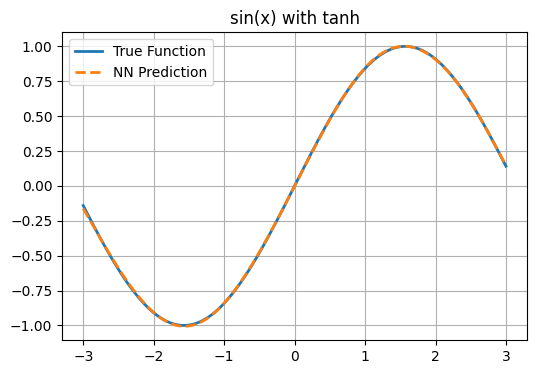


 training on x^2 with tanh
Epoch: 0, Loss:  17.203716
Epoch: 100, Loss:  6.214908
Epoch: 200, Loss:  1.223439
Epoch: 300, Loss:  0.517430
Epoch: 400, Loss:  0.236874
Epoch: 500, Loss:  0.114324
Epoch: 600, Loss:  0.060603
Epoch: 700, Loss:  0.037421
Epoch: 800, Loss:  0.026295
Epoch: 900, Loss:  0.019791
Epoch: 1000, Loss:  0.015337
Epoch: 1100, Loss:  0.012012
Epoch: 1200, Loss:  0.009440
Epoch: 1300, Loss:  0.007431
Epoch: 1400, Loss:  0.005863
Epoch: 1500, Loss:  0.004648
Epoch: 1600, Loss:  0.003714
Epoch: 1700, Loss:  0.002999
Epoch: 1800, Loss:  0.002454
Epoch: 1900, Loss:  0.002038


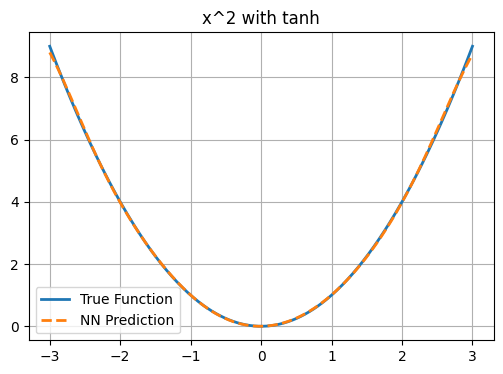


 training on triangle wave with tanh
Epoch: 0, Loss:  0.354932
Epoch: 100, Loss:  0.322825
Epoch: 200, Loss:  0.206214
Epoch: 300, Loss:  0.060022
Epoch: 400, Loss:  0.008820
Epoch: 500, Loss:  0.004312
Epoch: 600, Loss:  0.003496
Epoch: 700, Loss:  0.003067
Epoch: 800, Loss:  0.002745
Epoch: 900, Loss:  0.002484
Epoch: 1000, Loss:  0.002255
Epoch: 1100, Loss:  0.002053
Epoch: 1200, Loss:  0.001871
Epoch: 1300, Loss:  0.001717
Epoch: 1400, Loss:  0.001558
Epoch: 1500, Loss:  0.001437
Epoch: 1600, Loss:  0.001304
Epoch: 1700, Loss:  0.001197
Epoch: 1800, Loss:  0.001156
Epoch: 1900, Loss:  0.001002


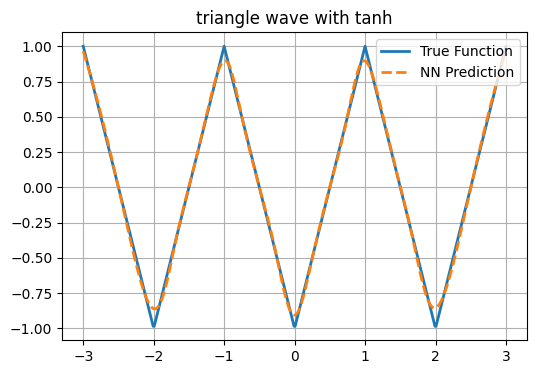


 training on square wave with tanh
Epoch: 0, Loss:  1.045921
Epoch: 100, Loss:  0.976139
Epoch: 200, Loss:  0.966480
Epoch: 300, Loss:  0.957769
Epoch: 400, Loss:  0.947985
Epoch: 500, Loss:  0.932757
Epoch: 600, Loss:  0.887127
Epoch: 700, Loss:  0.777503
Epoch: 800, Loss:  0.629358
Epoch: 900, Loss:  0.525465
Epoch: 1000, Loss:  0.456405
Epoch: 1100, Loss:  0.398850
Epoch: 1200, Loss:  0.332019
Epoch: 1300, Loss:  0.192457
Epoch: 1400, Loss:  0.169418
Epoch: 1500, Loss:  0.161700
Epoch: 1600, Loss:  0.156490
Epoch: 1700, Loss:  0.151538
Epoch: 1800, Loss:  0.146532
Epoch: 1900, Loss:  0.141414


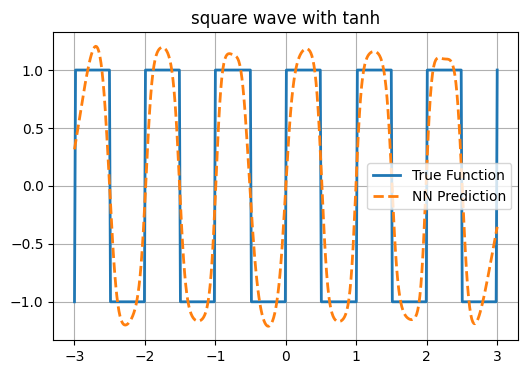

In [ ]:
run("tanh")


 training on sin(x) with relu
Epoch: 0, Loss:  0.690579
Epoch: 100, Loss:  0.068795
Epoch: 200, Loss:  0.015384
Epoch: 300, Loss:  0.003694
Epoch: 400, Loss:  0.001166
Epoch: 500, Loss:  0.000478
Epoch: 600, Loss:  0.000236
Epoch: 700, Loss:  0.000134
Epoch: 800, Loss:  0.000083
Epoch: 900, Loss:  0.000055
Epoch: 1000, Loss:  0.000038
Epoch: 1100, Loss:  0.000028
Epoch: 1200, Loss:  0.000021
Epoch: 1300, Loss:  0.000017
Epoch: 1400, Loss:  0.000014
Epoch: 1500, Loss:  0.000011
Epoch: 1600, Loss:  0.000010
Epoch: 1700, Loss:  0.000009
Epoch: 1800, Loss:  0.000008
Epoch: 1900, Loss:  0.000007


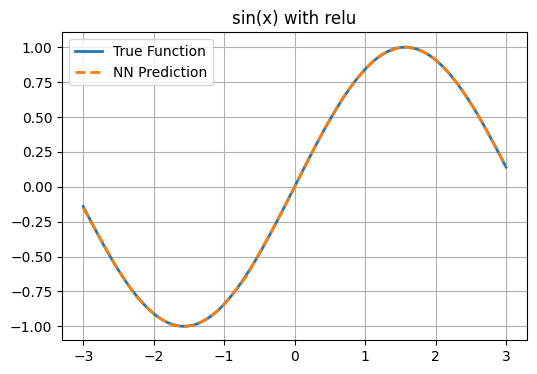


 training on x^2 with relu
Epoch: 0, Loss:  15.569147
Epoch: 100, Loss:  1.987472
Epoch: 200, Loss:  0.418532
Epoch: 300, Loss:  0.192794
Epoch: 400, Loss:  0.104907
Epoch: 500, Loss:  0.060164
Epoch: 600, Loss:  0.035357
Epoch: 700, Loss:  0.021921
Epoch: 800, Loss:  0.014446
Epoch: 900, Loss:  0.010005
Epoch: 1000, Loss:  0.007209
Epoch: 1100, Loss:  0.005365
Epoch: 1200, Loss:  0.004102
Epoch: 1300, Loss:  0.003195
Epoch: 1400, Loss:  0.002510
Epoch: 1500, Loss:  0.001978
Epoch: 1600, Loss:  0.001569
Epoch: 1700, Loss:  0.001257
Epoch: 1800, Loss:  0.001022
Epoch: 1900, Loss:  0.000849


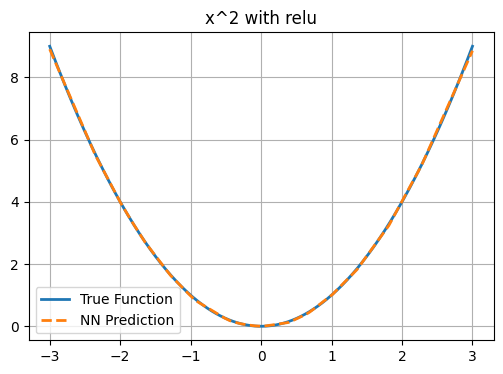


 training on triangle wave with relu
Epoch: 0, Loss:  0.351359
Epoch: 100, Loss:  0.274228
Epoch: 200, Loss:  0.142382
Epoch: 300, Loss:  0.030688
Epoch: 400, Loss:  0.000864
Epoch: 500, Loss:  0.000166
Epoch: 600, Loss:  0.000106
Epoch: 700, Loss:  0.000082
Epoch: 800, Loss:  0.000038
Epoch: 900, Loss:  0.000043
Epoch: 1000, Loss:  0.000021
Epoch: 1100, Loss:  0.000016
Epoch: 1200, Loss:  0.000013
Epoch: 1300, Loss:  0.000011
Epoch: 1400, Loss:  0.000009
Epoch: 1500, Loss:  0.000015
Epoch: 1600, Loss:  0.000007
Epoch: 1700, Loss:  0.000006
Epoch: 1800, Loss:  0.000016
Epoch: 1900, Loss:  0.000005


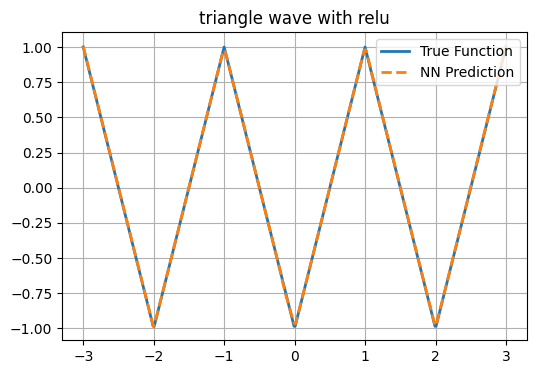


 training on square wave with relu
Epoch: 0, Loss:  1.050392
Epoch: 100, Loss:  0.950796
Epoch: 200, Loss:  0.872358
Epoch: 300, Loss:  0.702074
Epoch: 400, Loss:  0.534588
Epoch: 500, Loss:  0.414700
Epoch: 600, Loss:  0.341720
Epoch: 700, Loss:  0.299793
Epoch: 800, Loss:  0.267671
Epoch: 900, Loss:  0.247038
Epoch: 1000, Loss:  0.232072
Epoch: 1100, Loss:  0.219570
Epoch: 1200, Loss:  0.209452
Epoch: 1300, Loss:  0.200750
Epoch: 1400, Loss:  0.192521
Epoch: 1500, Loss:  0.185770
Epoch: 1600, Loss:  0.179458
Epoch: 1700, Loss:  0.173817
Epoch: 1800, Loss:  0.168278
Epoch: 1900, Loss:  0.163119


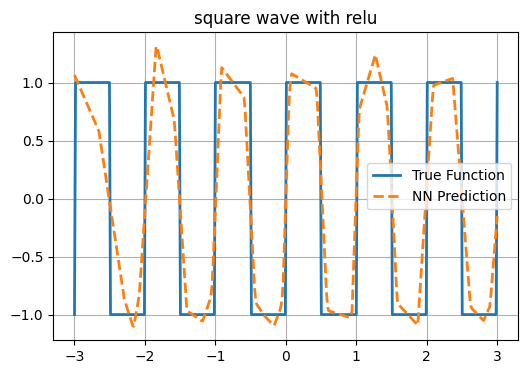

In [ ]:
run('relu')